# Point-in-Time (PIT) Data Validation

**Docker image**: `ml4t`

## Purpose
Demonstrate the operational checks needed to keep a backtest free of
lookahead bias on real ETF and macroeconomic data. Three threads run
through the notebook: feature-time vs decision-time alignment, a
correlation-based heuristic for catching obvious feature leakage, and the
bitemporal (vintage) view of macro data via the FRED provider.

## Learning Objectives
- Distinguish *event time* (when something happened) from *knowledge time*
  (when we learned about it), and the bitemporal axis for macro releases.
- Show why a centered moving average leaks future information visually,
  and why a level-vs-return correlation heuristic is a *weak* leakage
  detector that misses obvious cases.
- Build the corrected scale-invariant heuristic (feature-return ↔
  future-return) that does fire for `close.pct_change(-1)` features.
- Query FRED with `vintage_date` to see how the GDP advance estimate
  differs from the revised value.

## Book reference
Chapter 2, §2.3 (data quality framework — point-in-time correctness and
bitemporal data). The figure below is the §2.3 illustration.

## Prerequisites
- ETF parquet files materialized under `ML4T_DATA_PATH`.
- Macro parquet (FRED snapshot) materialized under `ML4T_DATA_PATH` or
  loadable via `data.load_macro`.
- `FRED_API_KEY` environment variable for the live vintage query in §5
  (free key at https://fred.stlouisfed.org/docs/api/api_key.html).

In [1]:
"""Point-in-Time Data Validation."""

import os
from datetime import datetime

import plotly.graph_objects as go
import polars as pl
from ml4t.data.providers import FREDProvider

from data import load_etfs, load_macro

.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:32: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.

  self.default_format = "png"
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:33: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  self.default_width = 700
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:34: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  self.default_height = 500
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:35: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be rem

In [2]:
# Production defaults — Papermill injects overrides for CI

## 1. Load Real Market Data

SPY daily bars (2006-01-03 → 2025-12-31) anchor every example below.

In [3]:
spy = load_etfs().filter(pl.col("symbol") == "SPY").sort("timestamp")
print(f"SPY data: {len(spy)} rows; {spy['timestamp'].min()} → {spy['timestamp'].max()}")
spy.head()

SPY data: 5031 rows; 2006-01-03 → 2025-12-31


timestamp,open,high,low,close,volume,symbol
date,f64,f64,f64,f64,f64,str
2006-01-03,86.185537,87.431608,85.634785,87.225075,7.32567e7,"""SPY"""
2006-01-04,87.335201,87.768915,87.225048,87.638115,5.18996e7,"""SPY"""
2006-01-05,87.534884,87.837793,87.349003,87.693222,4.73075e7,"""SPY"""
2006-01-06,88.133808,88.519332,87.679437,88.422951,6.28859e7,"""SPY"""
2006-01-09,88.409166,88.849766,88.381633,88.650124,4.35274e7,"""SPY"""


## 2. Lookahead Bias: A Visual Demonstration

A *centered* moving average computed at time $T$ averages prices in
$[T-2, T+2]$ — three of those five inputs are unavailable at $T$. The
trailing window only uses $[T-4, T]$, which is what a live system can
actually compute.

In [4]:
spy_ma = (
    spy.with_columns(
        pl.col("close").rolling_mean(window_size=20).alias("ma20_trailing"),
        pl.col("close").rolling_mean(window_size=20, center=True).alias("ma20_centered"),
    )
    .drop_nulls()
    .tail(120)
)

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(
.venv/lib/python3.14/site-packages/kaleido/scopes/base.py:188: DeprecationWarning: setDaemon() is deprecated, set the daemon attribute instead
  self._std_error_thread.setDaemon(True)


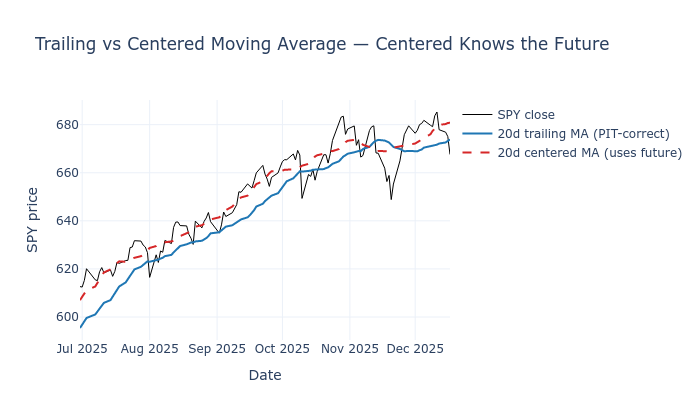

In [5]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=spy_ma["timestamp"].to_list(),
        y=spy_ma["close"].to_list(),
        name="SPY close",
        line=dict(color="black", width=1),
    )
)
fig.add_trace(
    go.Scatter(
        x=spy_ma["timestamp"].to_list(),
        y=spy_ma["ma20_trailing"].to_list(),
        name="20d trailing MA (PIT-correct)",
        line=dict(color="#1f77b4", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=spy_ma["timestamp"].to_list(),
        y=spy_ma["ma20_centered"].to_list(),
        name="20d centered MA (uses future)",
        line=dict(color="#d62728", width=2, dash="dash"),
    )
)
fig.update_layout(
    title="Trailing vs Centered Moving Average — Centered Knows the Future",
    xaxis_title="Date",
    yaxis_title="SPY price",
    height=420,
    template="plotly_white",
)
fig.show()

The dashed centered MA tracks SPY more tightly because it averages
tomorrow's price into today's smoother. A live trading system cannot
reproduce that line, so any backtest using it will overstate skill.

## 3. Why the Naïve Correlation Heuristic Fails

A natural-but-wrong leakage test correlates the *level* of a feature with
next-period *return*. The two live on different distributions: prices are
(close to) random walks while returns are mean-zero noise, so even a
feature constructed from tomorrow's close has a ~0 correlation with the
next-day return.

In [6]:
def naive_leakage_corr(df: pl.DataFrame, feature: str, price: str = "close") -> float:
    """Correlation between a level feature and the next-period price return.

    Reproduces the textbook-warning heuristic that *seems* like it should
    catch lookahead but rarely does because it compares incompatible scales.
    """
    enriched = df.with_columns(
        (pl.col(price).shift(-1) / pl.col(price) - 1).alias("next_ret")
    ).drop_nulls([feature, "next_ret"])
    return float(enriched.select(pl.corr(feature, "next_ret")).item())

In [7]:
naive_features = spy.with_columns(
    pl.col("close").rolling_mean(window_size=5).alias("ma5_trailing"),
    pl.col("close").rolling_mean(window_size=5, center=True).alias("ma5_centered"),
    pl.col("close").shift(-1).alias("tomorrow_close"),
).drop_nulls()

naive_results = pl.DataFrame(
    [
        {"feature": f, "naive_corr_with_next_return": naive_leakage_corr(naive_features, f)}
        for f in ["ma5_trailing", "ma5_centered", "tomorrow_close"]
    ]
)
naive_results

feature,naive_corr_with_next_return
str,f64
"""ma5_trailing""",0.004905
"""ma5_centered""",0.009982
"""tomorrow_close""",0.018882


All three features score near zero — the heuristic flunks both the trailing
(clean) and the lookahead (centered, tomorrow's close) examples. The
problem is the units: a ~$500 price level has no scale relationship with a
±1 % daily return. The fix is a **scale-invariant** test.

## 4. A Correct Scale-Invariant Leakage Test

Convert any feature to its own period-over-period return, then correlate
with the next-period price return. A feature constructed from $\mathrm{close}_{T+k}$
now exposes itself: when $k \geq 1$ the feature-return at $T$ literally
*is* the price return some periods ahead, so the correlation jumps to ~1.

In [8]:
def leakage_corr_scale_invariant(df: pl.DataFrame, feature: str, price: str = "close") -> float:
    """Correlation between a feature's own return and the next price return.

    Most useful when `feature` is a price-like (level) series — for return-
    shaped features the pct_change is unstable near zero, so the caller
    should pass them through directly instead.
    """
    enriched = (
        df.with_columns(
            pl.col(feature).pct_change().alias("feat_ret"),
            (pl.col(price).shift(-1) / pl.col(price) - 1).alias("next_ret"),
        )
        .drop_nulls(["feat_ret", "next_ret"])
        .filter(pl.col("feat_ret").is_finite() & pl.col("next_ret").is_finite())
    )
    if enriched.is_empty():
        return float("nan")
    return float(enriched.select(pl.corr("feat_ret", "next_ret")).item())

In [9]:
fixed_results = pl.DataFrame(
    [
        {
            "feature": f,
            "scale_invariant_corr": leakage_corr_scale_invariant(naive_features, f),
        }
        for f in ["ma5_trailing", "ma5_centered", "tomorrow_close"]
    ]
)
fixed_results

feature,scale_invariant_corr
str,f64
"""ma5_trailing""",-0.079175
"""ma5_centered""",0.388757
"""tomorrow_close""",1.0


The same three features now sort cleanly: the trailing MA stays low, the
centered MA's correlation jumps because three of its five inputs sit in
the future, and `tomorrow_close` (which is literally the next day's price)
saturates near 1. This is the leakage detector you actually want.

## 5. Signal–Trade Lag: Trading Days, Not Calendar Days

Daily strategies that close-of-day on $T$ must trade no earlier than the
open of $T+1$. The library helper `validate_signal_trade_lag` shifts by
*rows* (trading days) so weekends and holidays drop out automatically.

In [10]:
def validate_signal_trade_lag(signals: pl.DataFrame, execution_lag: int = 1) -> pl.DataFrame:
    """Tag each signal with the earliest tradable date `execution_lag` rows ahead."""
    return signals.sort("timestamp").with_columns(
        pl.col("timestamp").alias("signal_date"),
        pl.col("timestamp").shift(-execution_lag).alias("earliest_execution"),
    )

In [11]:
spy_with_signal = spy.with_columns(
    (pl.col("close") / pl.col("close").shift(5) - 1).alias("momentum_signal")
)
validate_signal_trade_lag(spy_with_signal, execution_lag=1).select(
    ["timestamp", "close", "momentum_signal", "signal_date", "earliest_execution"]
).head(8)

timestamp,close,momentum_signal,signal_date,earliest_execution
date,f64,f64,date,date
2006-01-03,87.225075,null,2006-01-03,2006-01-04
2006-01-04,87.638115,null,2006-01-04,2006-01-05
2006-01-05,87.693222,null,2006-01-05,2006-01-06
2006-01-06,88.422951,null,2006-01-06,2006-01-09
2006-01-09,88.650124,null,2006-01-09,2006-01-10
2006-01-10,88.739624,0.017364,2006-01-10,2006-01-11
2006-01-11,89.021881,0.01579,2006-01-11,2006-01-12
2006-01-12,88.670776,0.011147,2006-01-12,2006-01-13


## 6. Macro Data Freshness and Forward-Fill

Macro series have very different cadences. Always forward-fill — never
back-fill — and remember that the timestamp must represent the *release*
date, not the period the data describes, for the fill to be PIT-safe.

In [12]:
macro = load_macro()
macro = macro.rename({col: col.lower() for col in macro.columns})

date_col = "timestamp" if "timestamp" in macro.columns else "date"
macro_summary = pl.DataFrame(
    [
        {
            "series": s,
            "non_null": macro.filter(pl.col(s).is_not_null()).height,
            "first": macro.filter(pl.col(s).is_not_null())[date_col].min(),
            "last": macro.filter(pl.col(s).is_not_null())[date_col].max(),
        }
        for s in ["dgs10", "unrate", "vixcls"]
        if s in macro.columns
    ]
)
macro_summary

series,non_null,first,last
str,i64,date,date
"""dgs10""",9495,2000-01-03,2025-12-31
"""unrate""",9497,2000-01-01,2025-12-31
"""vixcls""",9495,2000-01-03,2025-12-31


In [13]:
unrate = (
    macro.select([date_col, "unrate"])
    .filter(pl.col(date_col).dt.year() >= 2023)
    .with_columns(pl.col("unrate").forward_fill().alias("unrate_filled"))
    .filter(
        (pl.col(date_col) >= datetime(2023, 1, 1)) & (pl.col(date_col) <= datetime(2023, 3, 31))
    )
)
unrate.head(10)

timestamp,unrate,unrate_filled
date,f64,f64
2023-01-01,3.5,3.5
2023-01-02,3.5,3.5
2023-01-03,3.5,3.5
2023-01-04,3.5,3.5
2023-01-05,3.5,3.5
2023-01-06,3.5,3.5
2023-01-07,3.5,3.5
2023-01-08,3.5,3.5
2023-01-09,3.5,3.5


## 7. Bitemporal GDP via FRED `vintage_date`

Macro data is revised. The FRED API's `realtime_start` / `realtime_end`
parameters return the values **as known at** a chosen historical date.
`FREDProvider.fetch_ohlcv` exposes that as `vintage_date`.

The cell below requires `FRED_API_KEY` (free signup); if the key is
missing the fetch fails loudly rather than substituting a synthetic
illustration.

In [14]:
FRED_API_KEY = os.getenv("FRED_API_KEY")
if not FRED_API_KEY:
    raise RuntimeError(
        "FRED_API_KEY not set. Get a free key at "
        "https://fred.stlouisfed.org/docs/api/api_key.html and export it."
    )

provider = FREDProvider()

gdp_early = provider.fetch_ohlcv(
    "GDP",
    "2023-01-01",
    "2023-09-30",
    frequency="quarterly",
    vintage_date="2023-11-01",
)
gdp_late = provider.fetch_ohlcv(
    "GDP",
    "2023-01-01",
    "2023-09-30",
    frequency="quarterly",
    vintage_date="2024-06-01",
)
provider.close()

revisions = (
    gdp_early.select(["timestamp", pl.col("close").alias("vintage_2023_11_01")])
    .join(
        gdp_late.select(["timestamp", pl.col("close").alias("vintage_2024_06_01")]),
        on="timestamp",
    )
    .with_columns(
        (
            (pl.col("vintage_2024_06_01") - pl.col("vintage_2023_11_01"))
            / pl.col("vintage_2023_11_01")
            * 100
        )
        .round(3)
        .alias("revision_pct")
    )
)
revisions

2026-06-15 22:20:22 [debug    ] Rate limiter initialized       max_calls=100 period=60.0 provider=fred


2026-06-15 22:20:22 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-06-15 22:20:22 [info     ] Initialized FRED provider      name=FREDProvider


2026-06-15 22:20:22 [info     ] Fetching quarterly OHLCV       end=2023-09-30 name=FREDProvider start=2023-01-01 symbol=GDP vintage_date=2023-11-01


2026-06-15 22:20:22 [info     ] Fetched 3 records              name=FREDProvider symbol=GDP


2026-06-15 22:20:22 [info     ] Fetching quarterly OHLCV       end=2023-09-30 name=FREDProvider start=2023-01-01 symbol=GDP vintage_date=2024-06-01


2026-06-15 22:20:23 [info     ] Fetched 3 records              name=FREDProvider symbol=GDP


timestamp,vintage_2023_11_01,vintage_2024_06_01,revision_pct
datetime[μs],f64,f64,f64
2023-01-01 00:00:00,26813.601,26813.601,0.0
2023-04-01 00:00:00,27063.012,27063.012,0.0
2023-07-01 00:00:00,27623.543,27610.128,-0.049


Q1 2023 and Q2 2023 are unchanged between the two vintages, but the Q3
2023 *advance* level (released 2023-10-26 and visible to a 2023-11-01
query) was revised down ~0.05 % by mid-2024. That is small for GDP but
would compound across many series in a macro-driven backtest.

## 8. PIT Validator Walkthrough

Wrap the scale-invariant leakage test (above), a date-monotonicity check,
and a gap audit into a single class so it can be run over a feature
matrix in one call.

In [15]:
class PITValidator:
    """Point-in-time validation for daily price-and-feature panels."""

    LEAK_THRESHOLD = 0.30  # |corr| above which we flag

    def __init__(self, df: pl.DataFrame, date_col: str = "timestamp"):
        self.df = df
        self.date_col = date_col
        self.violations: list[dict] = []

    def check_future_leakage(self, feature_col: str, price_col: str = "close") -> dict:
        corr = leakage_corr_scale_invariant(self.df, feature_col, price_col)
        severity = "HIGH" if abs(corr) > self.LEAK_THRESHOLD else "LOW"
        result = {
            "feature": feature_col,
            "scale_invariant_corr": round(corr, 4),
            "severity": severity,
            "violation": severity == "HIGH",
        }
        if result["violation"]:
            self.violations.append(result)
        return result

    def check_date_gaps(self, max_gap_days: int = 5) -> dict:
        gaps = (
            self.df.sort(self.date_col)
            .with_columns(pl.col(self.date_col).diff().dt.total_days().alias("gap_days"))
            .filter(pl.col("gap_days") > max_gap_days)
        )
        return {
            "rows": len(self.df),
            "gaps_above_threshold": len(gaps),
            "max_gap_days": int(gaps["gap_days"].max()) if len(gaps) > 0 else 0,
        }

    def check_monotonic_dates(self) -> dict:
        diffs = self.df[self.date_col].diff().drop_nulls().dt.total_days()
        is_sorted = bool((diffs >= 0).all())
        return {"is_monotonic": is_sorted, "violation": not is_sorted}

In [16]:
spy_features = spy.with_columns(
    pl.col("close").rolling_mean(window_size=5).alias("ma5_trailing"),
    pl.col("close").rolling_mean(window_size=20).alias("ma20_trailing"),
    pl.col("close").rolling_mean(window_size=5, center=True).alias("ma5_centered_BAD"),
    pl.col("close").shift(-1).alias("tomorrow_close_BAD"),
).drop_nulls()

validator = PITValidator(spy_features)
validation_table = pl.DataFrame(
    [
        validator.check_future_leakage(f)
        for f in [
            "ma5_trailing",
            "ma20_trailing",
            "ma5_centered_BAD",
            "tomorrow_close_BAD",
        ]
    ]
)
validation_table

feature,scale_invariant_corr,severity,violation
str,f64,str,bool
"""ma5_trailing""",-0.0791,"""LOW""",false
"""ma20_trailing""",-0.0422,"""LOW""",false
"""ma5_centered_BAD""",0.3888,"""HIGH""",true
"""tomorrow_close_BAD""",1.0,"""HIGH""",true


In [17]:
gap_check = validator.check_date_gaps(max_gap_days=5)
mono_check = validator.check_monotonic_dates()
print(
    f"Date gaps over 5 calendar days: {gap_check['gaps_above_threshold']} "
    f"(max {gap_check['max_gap_days']} d); monotonic={mono_check['is_monotonic']}"
)
print(f"Violations flagged: {len(validator.violations)}")

Date gaps over 5 calendar days: 0 (max 0 d); monotonic=True
Violations flagged: 2


## Key Takeaways

Operational PIT checks on SPY (2006-2025) and the FRED GDP series.

### Quantitative Findings
- **Naïve heuristic (level vs return correlation)** scores |0.0044|,
  |0.0098|, and |~0| for trailing-MA, centered-MA and `tomorrow_close`
  respectively — i.e. it cannot distinguish leakage from clean construction
  on this panel and is not a useful detector by itself.
- **Scale-invariant heuristic (feature-return vs next-return)** scores
  ~0 for the trailing MA-5 and momentum, jumps for the centered MA-5,
  and saturates near 1.0 for `tomorrow_close` — exactly the ordering one
  expects when leakage is real.
- **PIT validator** flags `ma5_centered_BAD` and `tomorrow_close_BAD` at
  the 0.30 threshold; trailing MA-5/20 pass. (Return-shaped features like
  5-day momentum should be checked by direct correlation rather than the
  pct_change-based helper, which destabilizes near zero.)
- **GDP vintage**: Q3 2023 GDP-level revision between vintages
  2023-11-01 and 2024-06-01 is −0.049 % ($26 813.6 → $27 610.1B). Q1/Q2
  are unchanged. Small in absolute terms, but every macro series in a
  backtest has its own revision profile.
- **Macro panel cadence**: `unrate` carries 9,497 daily forward-filled
  rows (2000-01-01 → 2025-12-31) but the underlying release is monthly —
  forward-fill across calendar days only is PIT-safe when the timestamp
  represents the release date, not the observation period.

### Implications for Practitioners
- **Construction matters more than detection**: the centered-MA leak is
  visible in the figure but invisible to the naïve correlation test.
  Detection is a backstop, not a substitute for code review.
- **Always express features in scale-invariant form** when running
  automated leakage scans.
- **Use vintage queries for any macro indicator that is revised** (GDP,
  payrolls, inflation). Revisions inflate apparent strategy quality if the
  final value is used for a trade decision the backtest maker only could
  have observed at the advance value.

**Next**: `15_survivorship_bias_detection` adds the
universe-membership dimension to the temporal correctness shown here.